#
MNIST Handwritten Digit Classification Using Neural Network

This project builds a simple neural network to classify handwritten digits from 0 to 9 using the MNIST dataset.
The project covers:
- Dataset understanding
- Data preprocessing
- Neural network construction
- Activation functions
- Model training
- Model evaluation
- Confusion matrix
- Model experimentation

In [67]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

In [68]:
# Load the MNIST dataset and prints the size of the training and testing data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [69]:
# Check data set details image size, pixel range and labels
print("Image size:", x_train[0].shape)
print("Pixel range:", x_train.min(), "to", x_train.max())
print("Classes:", np.unique(y_train))

Image size: (28, 28)
Pixel range: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8 9]


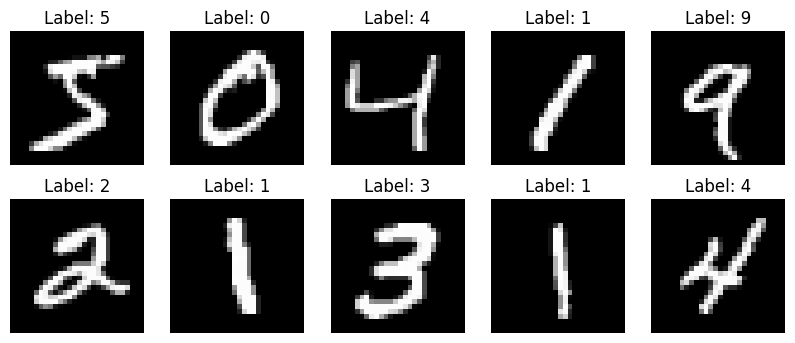

In [70]:
# Display sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")
plt.show()

###
Dataset
MNIST contains handwritten digit images.
- Image size: 28 × 28 pixels
- Number of classes: 10
- Classes: 0 to 9
- Each image is grayscale

In [71]:
#Normalizes the image pixels from the range 0–255 to 0–1.
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
print("New pixel range:", x_train.min(), "to", x_train.max())

New pixel range: 0.0 to 1.0


In [72]:
#images are available for training and testing.
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 60000
Testing samples: 10000


In [73]:
# Build the neural network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ReLU

ReLU is used in the hidden layer.
It changes negative values to 0 and keeps positive values.

Softmax

Softmax is used in the output layer.
It gives probabilities for the 10 digit classes.

In [75]:
#Train the model
history = model.fit( x_train,y_train,epochs=5,batch_size=32,validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9243 - loss: 0.2661 - val_accuracy: 0.9668 - val_loss: 0.1248
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9647 - loss: 0.1198 - val_accuracy: 0.9752 - val_loss: 0.0894
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9756 - loss: 0.0820 - val_accuracy: 0.9763 - val_loss: 0.0806
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9817 - loss: 0.0614 - val_accuracy: 0.9743 - val_loss: 0.0950
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9848 - loss: 0.0478 - val_accuracy: 0.9800 - val_loss: 0.0736


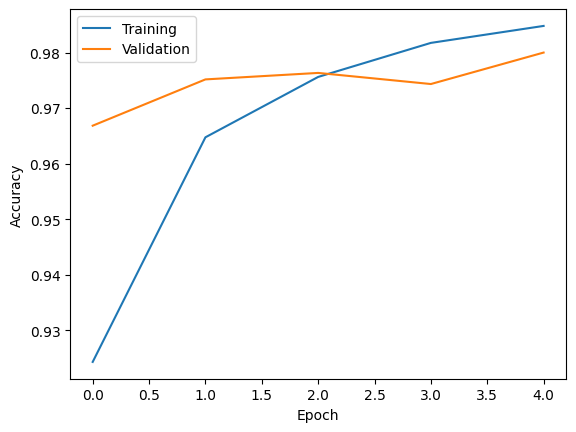

In [76]:
#Plot accuracy
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

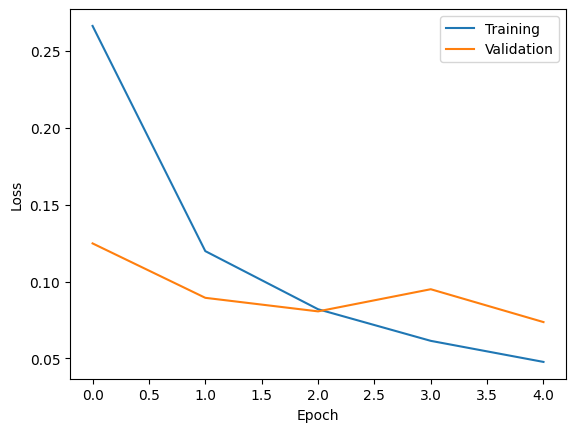

In [77]:
#Plot loss
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [78]:
#Test the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9767 - loss: 0.0727
Test Loss: 0.072669118642807
Test Accuracy: 0.9767000079154968


In [79]:
#Make predictions
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
print("Predicted:", y_pred[:10])
print("Actual:   ", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: [7 2 1 0 4 1 4 9 6 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


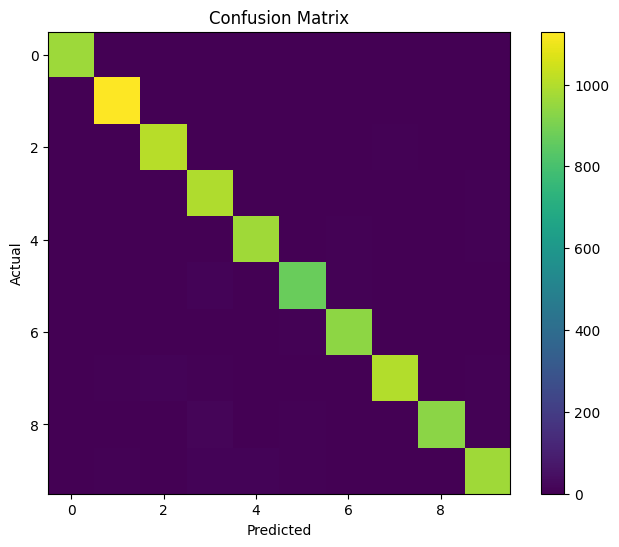

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.95      0.98      0.97      1010
           4       0.98      0.99      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.99      0.96      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [80]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))

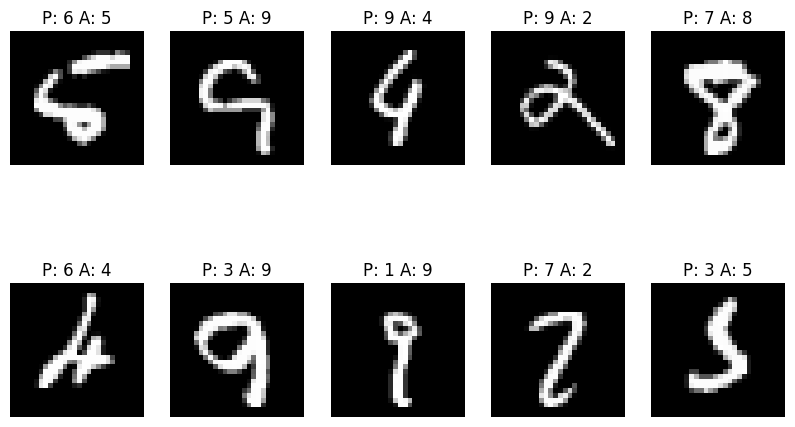

In [81]:
#Check wrong predictions
wrong = np.where(y_pred != y_test)[0]
plt.figure(figsize=(10, 6))
for i in range(10):
    index = wrong[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index], cmap="gray")
    plt.title("P: " + str(y_pred[index]) + " A: " + str(y_test[index]))
    plt.axis("off")
plt.show()

Experiment

I changed the number of neurons in the hidden layer from 128 to 64.

In [82]:
#Create modified model
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [83]:
#Train modified model
history2 = model2.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9073 - loss: 0.3270 - val_accuracy: 0.9597 - val_loss: 0.1459
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9549 - loss: 0.1547 - val_accuracy: 0.9622 - val_loss: 0.1259
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9672 - loss: 0.1103 - val_accuracy: 0.9747 - val_loss: 0.0934
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9741 - loss: 0.0865 - val_accuracy: 0.9713 - val_loss: 0.0958
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9791 - loss: 0.0704 - val_accuracy: 0.9760 - val_loss: 0.0889


In [84]:
#Test modified model
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)
print("Modified Model Test Loss:", test_loss2)
print("Modified Model Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9722 - loss: 0.0928
Modified Model Test Loss: 0.09282948076725006
Modified Model Test Accuracy: 0.9721999764442444


In [85]:
#Compare the models
print("Original model accuracy:", test_accuracy)
print("Modified model accuracy:", test_accuracy2)

Original model accuracy: 0.9767000079154968
Modified model accuracy: 0.9721999764442444


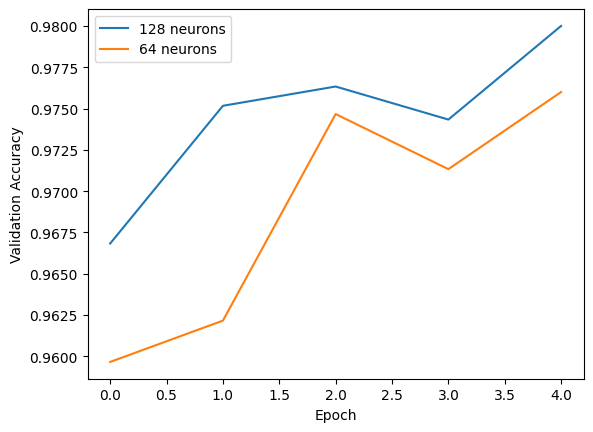

In [86]:
#Compare validation accuracy
plt.plot(history.history["val_accuracy"], label="128 neurons")
plt.plot(history2.history["val_accuracy"], label="64 neurons")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Experiment Result

The original model used 128 neurons in the hidden layer and achieved a test accuracy of 97.65%.

The modified model used 64 neurons and achieved a test accuracy of 97.31%.

The accuracy decreased slightly after reducing the number of neurons. This is because fewer neurons give the hidden layer less capacity to learn patterns from the images.